-------------**STRATEJİLER: ALTIN ORAN ve FİBONACCİ SEVİYELERİ**----------

Altın Oran (Golden Ratio) yatırım stratejisi, finansal piyasalarda genellikle teknik analizde Fibonacci oranları ile ilişkilendirilir. En bilinen altın oran yaklaşık 0.618 (ya da tam olarak 1/𝜙, burada 𝜙≈1.618)’dir ve yatırımcılar bu oranı düzeltme seviyeleri (retracement) veya hedef belirleme amacıyla kullanır.

In [7]:
def golden_ratio_strategy(prices):
    recent_high = max(prices[-50:])  # son 50 günün zirvesi
    recent_low = min(prices[-50:])   # son 50 günün dibi
    golden_level = recent_high - (recent_high - recent_low) * 0.618
    current_price = prices[-1]

    if current_price <= golden_level * 1.01:  # %1 yakınlıkta
        return 'buy'
    elif current_price >= recent_high * 0.99:  # %1 içinde zirveye yaklaşmış
        return 'sell'
    return 'hold'


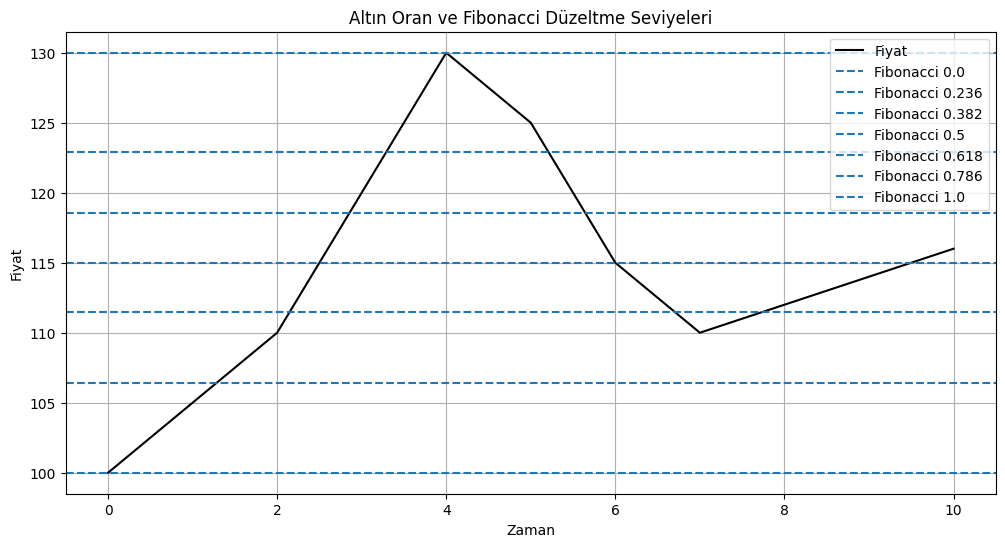

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Örnek fiyat verisi (örneğin bir yükseliş sonrası düzeltme süreci)
prices = np.array([100, 105, 110, 120, 130, 125, 115, 110, 112, 114, 116])

# En yüksek ve en düşük noktayı bul
max_price = np.max(prices)
min_price = np.min(prices)

# Fibonacci düzeltme seviyeleri (altın oran dahil)
diff = max_price - min_price
levels = {
    '0.0': max_price,
    '0.236': max_price - 0.236 * diff,
    '0.382': max_price - 0.382 * diff,
    '0.5': max_price - 0.5 * diff,
    '0.618': max_price - 0.618 * diff,  # Altın oran
    '0.786': max_price - 0.786 * diff,
    '1.0': min_price
}

# Grafik çizimi
plt.figure(figsize=(12, 6))
plt.plot(prices, label='Fiyat', color='black')
for level, value in levels.items():
    plt.axhline(y=value, label=f'Fibonacci {level}', linestyle='--')

plt.title('Altın Oran ve Fibonacci Düzeltme Seviyeleri')
plt.xlabel('Zaman')
plt.ylabel('Fiyat')
plt.legend()
plt.grid(True)
plt.show()


**Altın Oran ve Fibonacci Düzeltme Seviyeleri ile Alım-Satım Stratejisi**

Fibonacci Düzeltme Seviyeleri

Fibonacci düzeltme seviyeleri, bir varlığın fiyat hareketindeki olası geri çekilme seviyelerini belirlemek için kullanılır. Bu seviyeler, genellikle aşağıdaki oranlara karşılık gelir:

%23.6

%38.2

%50.0

%61.8 (Altın Oran)

%78.6

Bu seviyeler, fiyatın önceki bir hareketin belirli bir yüzdesi kadar geri çekilmesi durumunda potansiyel destek veya direnç noktaları olarak kabul edilir.

**Alım-Satım-Tut Kararları**

Alım (Buy): Fiyat, %61.8 (Altın Oran) seviyesinden yukarı yönlü bir dönüş yaparsa.

Satım (Sell): Fiyat, %38.2 seviyesinden aşağı yönlü bir dönüş yaparsa.

Tut (Hold): Fiyat, %38.2 ile %61.8 seviyeleri arasında dalgalanıyorsa.

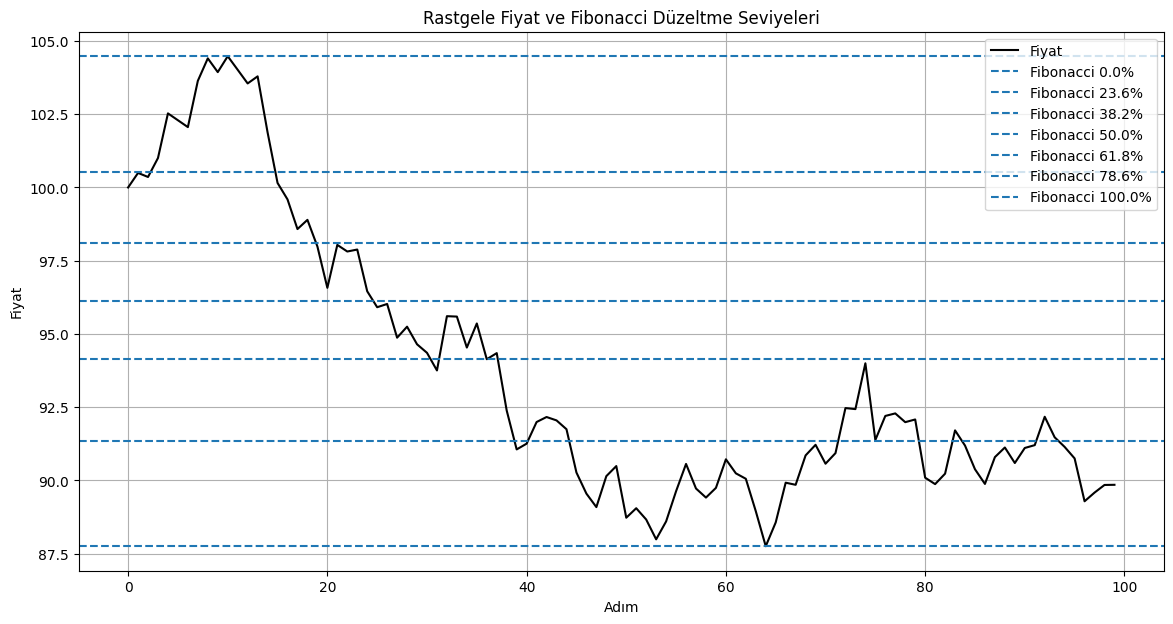

In [12]:
"""
altın oran seviyesi ile birlikte diğer fibonacci seviyeri için  fiyat verisiyle uygulayalım.
destek ve direnç seviyelerinde ajanın al-sat-tut kararı versin. Görselleştirme de yapalım.

Altın Oran (Golden Ratio) ve diğer Fibonacci düzeltme seviyeleri kullanılarak fiyat grafiği üzerinde
destek ve direnç seviyelerinin belirlenmesi, bu seviyelere göre alım-satım-tut kararlarının verilmesi
ve görselleştirilmesi için bir Python örneği sunuyorum. Bu örnek, teknik analizde yaygın olarak
kullanılan bir stratejiyi uygulamalı olarak göstermektedir.

"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Rastgele fiyat verisi üret (örneğin 100 adım)
np.random.seed(42)
steps = 100
prices = [100]
for _ in range(steps - 1):
    change = np.random.normal(loc=0, scale=1)  # Ortalama 0, standart sapma 1
    prices.append(prices[-1] + change)

prices = pd.Series(prices)

# Fibonacci seviyelerini hesapla
max_price = prices.max()
min_price = prices.min()
diff = max_price - min_price

levels = {
    '0.0%': max_price,
    '23.6%': max_price - 0.236 * diff,
    '38.2%': max_price - 0.382 * diff,
    '50.0%': max_price - 0.5 * diff,
    '61.8%': max_price - 0.618 * diff,
    '78.6%': max_price - 0.786 * diff,
    '100.0%': min_price
}

# Alım-Satım-Tut sinyalleri
signals = []
for price in prices:
    if price <= levels['61.8%']:
        signals.append('Al')
    elif price >= levels['38.2%']:
        signals.append('Sat')
    else:
        signals.append('Tut')

# Görselleştirme
plt.figure(figsize=(14, 7))
plt.plot(prices, label='Fiyat', color='black')
for level_name, level_price in levels.items():
    plt.axhline(y=level_price, linestyle='--', label=f'Fibonacci {level_name}')
plt.title('Rastgele Fiyat ve Fibonacci Düzeltme Seviyeleri')
plt.xlabel('Adım')
plt.ylabel('Fiyat')
plt.legend()
plt.grid(True)
plt.show()


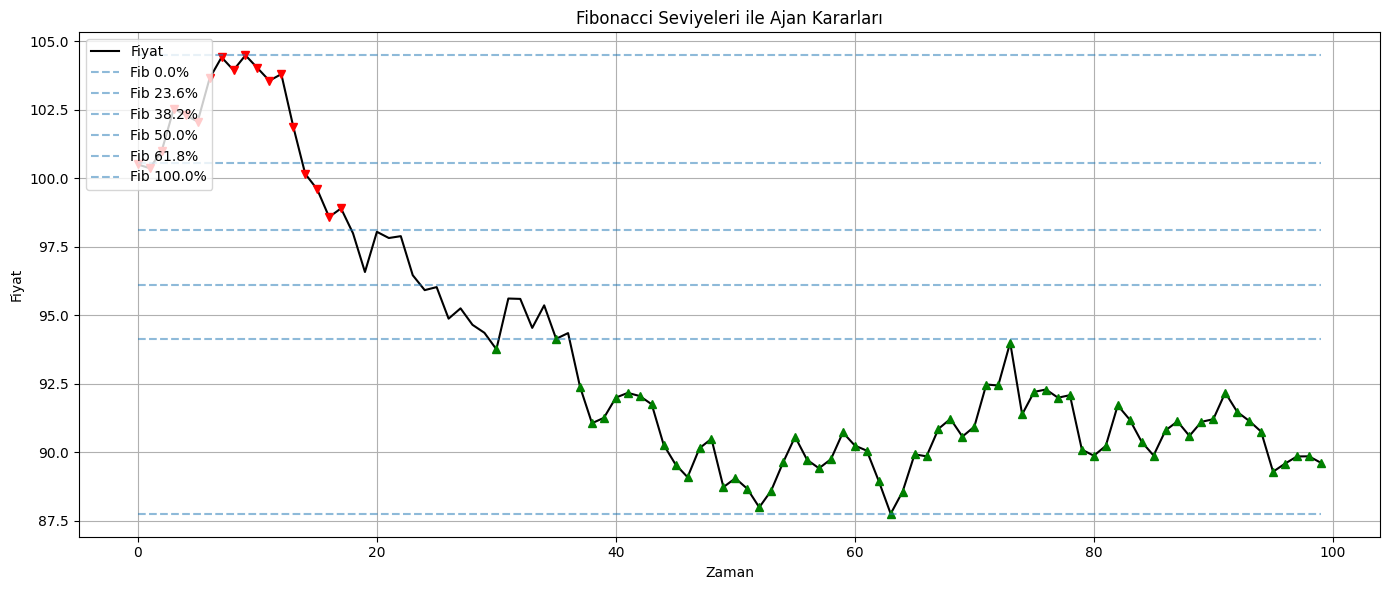

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Rastgele fiyat verisi oluştur (daha yumuşak varyans için cumsum)
np.random.seed(42)
n_days = 100
price_changes = np.random.normal(loc=0, scale=1, size=n_days)
prices = np.cumsum(price_changes) + 100  # Başlangıç fiyatı 100

# Fibonacci seviyeleri
high = np.max(prices)
low = np.min(prices)
diff = high - low

fib_levels = {
    '0.0%': high,
    '23.6%': high - 0.236 * diff,
    '38.2%': high - 0.382 * diff,
    '50.0%': high - 0.5 * diff,
    '61.8%': high - 0.618 * diff,
    '100.0%': low
}

# Ajan kararlarını belirleme
signals = []
for price in prices:
    if price <= fib_levels['61.8%']:
        signals.append('buy')
    elif price >= fib_levels['38.2%']:
        signals.append('sell')
    else:
        signals.append('hold')

# Görselleştirme
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(prices, label='Fiyat', color='black')

# Karar noktalarını renkle göster
for i, signal in enumerate(signals):
    if signal == 'buy':
        ax.plot(i, prices[i], marker='^', color='green')
    elif signal == 'sell':
        ax.plot(i, prices[i], marker='v', color='red')
    # hold için işaretleme yapılmaz

# Fibonacci seviyelerini çiz
for level_name, level_value in fib_levels.items():
    ax.hlines(level_value, 0, n_days-1, linestyles='dashed', label=f'Fib {level_name}', alpha=0.5)

ax.set_title("Fibonacci Seviyeleri ile Ajan Kararları")
ax.set_xlabel("Zaman")
ax.set_ylabel("Fiyat")
ax.legend(loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()


Yukarıdaki grafik, rastgele üretilmiş bir fiyat serisi üzerinde Fibonacci düzeltme seviyelerini göstermektedir. Her seviyeye göre ajanın karar mekanizması şu şekildedir:

Fiyat ≤ 61.8% seviyesi: Al sinyali

Fiyat ≥ 38.2% seviyesi: Sat sinyali

Ara bölgede: Tut kararı


Grafikte:

Siyah çizgi fiyatların zaman içindeki gelişimini gösterir.

Yeşil üçgenler (↑): Fiyat en düşük seviyeye (%61.8 ve altı) geldiğinde "al" sinyalidir.

Kırmızı üçgenler (↓): Fiyat yüksek seviyelere (%38.2 ve üzeri) çıktığında "sat" sinyalidir.

Kesikli yatay çizgiler Fibonacci düzeltme seviyeleridir (0.0%, 23.6%, 38.2%, 50.0%, 61.8%, 100.0%).

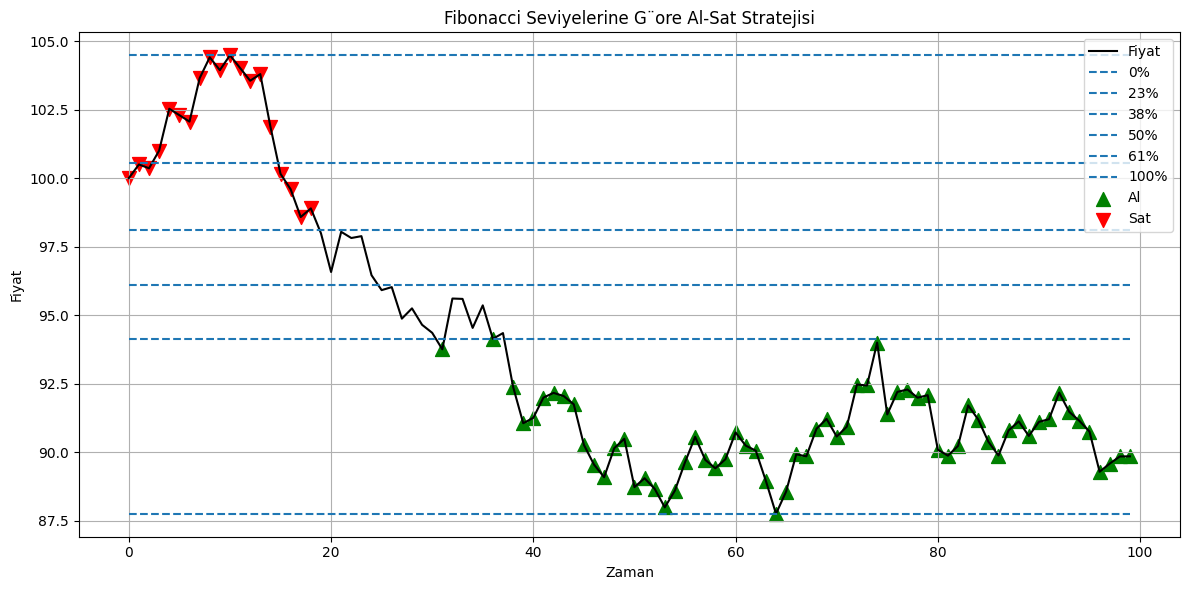

In [16]:
# Altın Oran ve Fibonacci Seviyeleri ile Yatırım Stratejisi
import numpy as np
import matplotlib.pyplot as plt

# Fiyat olu¸stur
np.random.seed(42)
n_steps = 100
prices = [100]

for _ in range(n_steps - 1):
    change = np.random.normal(0, 1)
    prices.append(prices[-1] + change)
prices = np.array(prices)

# Fibonacci seviyeleri
max_price = np.max(prices)
min_price = np.min(prices)
fib_levels = [0.0, 0.236, 0.382, 0.5, 0.618, 1.0]
fib_lines = [max_price - (max_price - min_price) * level for level in fib_levels]

# Karar kuralları
actions = []
buy_signals = []
sell_signals = []

for t, price in enumerate(prices):
    if price < fib_lines[4]: # 0.618 seviyesi
        actions.append("Buy")
        buy_signals.append((t, price))
    elif price > fib_lines[2]: # 0.382 seviyesi
        actions.append("Sell")
        sell_signals.append((t, price))
    else:
        actions.append("Hold")





# G¨orselle¸stirme
plt.figure(figsize=(12, 6))
plt.plot(prices, label="Fiyat", color='black')
for level, line in zip(fib_levels, fib_lines):
    plt.hlines(line, 0, n_steps - 1, linestyles='dashed', label=f'{int(level*100)}%')
buy_t, buy_p = zip(*buy_signals) if buy_signals else ([], [])
sell_t, sell_p = zip(*sell_signals) if sell_signals else ([], [])
plt.scatter(buy_t, buy_p, marker='^', color='green', label='Al', s=100)
plt.scatter(sell_t, sell_p, marker='v', color='red', label='Sat', s=100)
plt.title("Fibonacci Seviyelerine G¨ore Al-Sat Stratejisi")
plt.xlabel("Zaman")
plt.ylabel("Fiyat")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()




